# Africa Tiny U-Net v3 — strict consensus + GEE-screened no-fire negatives

This Colab notebook downloads a bounded Africa subset, creates strict voting masks, adds only safe non-fire patches, runs Ground Gate 1, trains a lightweight B10 Tiny U-Net, and exports the checkpoint, ONNX model, metrics, and figures.

In [1]:
!df -h /content
!pip -q install gdown rasterio tqdm pandas numpy matplotlib scipy onnx

from google.colab import drive
drive.mount("/content/drive")

PROJECT_ZIP = "/content/drive/MyDrive/thermal-edge-fire.zip"  # Change only if your ZIP is elsewhere.
assert __import__("os").path.exists(PROJECT_ZIP), f"Project ZIP not found: {PROJECT_ZIP}"

!rm -rf /content/thermal-edge-fire
!unzip -q "$PROJECT_ZIP" -d /content
%cd /content/thermal-edge-fire
print("Project extracted.")


Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  43% /
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 30.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
Mounted at /content/drive
/content/thermal-edge-fire
Project extracted.


In [2]:
from pathlib import Path

DATA_DIR = Path("/content")
AFRICA_ARCHIVE = DATA_DIR / "Africa.zip"

AFRICA_URL = "https://drive.google.com/file/d/1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX/view"

if not AFRICA_ARCHIVE.exists():
    !gdown --fuzzy "$AFRICA_URL" -O "$AFRICA_ARCHIVE"

assert AFRICA_ARCHIVE.exists(), "Africa.zip download failed."
print("Archive size (GB):", round(AFRICA_ARCHIVE.stat().st_size / 1024**3, 2))


Downloading...
From (original): https://drive.google.com/uc?id=1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX
From (redirected): https://drive.google.com/uc?id=1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX&confirm=t&uuid=6a1c514d-a471-414b-9651-8872c3d50b9f
To: /content/Africa.zip
100% 31.7G/31.7G [06:16<00:00, 84.0MB/s]
Archive size (GB): 29.49


In [4]:
!pip -q install earthengine-api rasterio requests tqdm pandas

import ee
import os
import io
import csv
import zipfile
import random
import requests
import rasterio
import numpy as np
import pandas as pd

# Create/select an Earth Engine-enabled Google Cloud project, then place its ID here.
GEE_PROJECT = "pure-object-509616-q6"

ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)

print("Earth Engine authenticated.")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine authenticated.


In [5]:
# ================================================================
# GEE NO-FIRE PATCH CREATION — AFRICA V3
#
# Uses raw Landsat 8 Collection 2 Tier 1 imagery, matching the
# raw-DN style of your ActiveFire workflow.
#
# Fire screening:
# - no MODIS FireMask class 7/8/9 within 12 km
# - screen ±8 days around the Landsat acquisition
# - reject cloudy / fill / shadow / snow patches
# ================================================================

from pathlib import Path
from tqdm.auto import tqdm

SEED = 42
TARGET_NEGATIVES = 150  # First validate 150. Later increase to 500–1,000.
MAX_ATTEMPTS = 2500

PATCH_PIXELS = 256
PIXEL_SIZE_M = 30
HALF_PATCH_M = PATCH_PIXELS * PIXEL_SIZE_M / 2  # 3,840 m
FIRE_EXCLUSION_M = 12_000
MAX_BAD_QA_FRACTION = 0.01

# Keep ten bands, where B10 and B11 have indexes 8 and 9.
# This matches your current project's channels=(8,) convention.
BANDS = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B9", "B10", "B11"]

GEE_ROOT = Path("/content/gee_nonfire_v3")
GEE_PATCH_DIR = GEE_ROOT / "patches"
GEE_MASK_DIR = GEE_ROOT / "masks" / "nonfire"
GEE_PATCH_DIR.mkdir(parents=True, exist_ok=True)
GEE_MASK_DIR.mkdir(parents=True, exist_ok=True)

LANDSAT = ee.ImageCollection("LANDSAT/LC08/C02/T1")
MODIS_FIRE = ee.ImageCollection("MODIS/061/MOD14A1")

# Prefer hot, difficult no-fire terrain; not only easy green background.
REGIONS = [
    ("north_africa_med", (-18, 27, 36, 46), 0.65),
    ("sub_saharan", (-18, -35, 52, 27), 0.35),
]

rng = random.Random(SEED)

def random_point():
    choice = rng.random()
    cumulative = 0.0

    for region_name, bounds, weight in REGIONS:
        cumulative += weight
        if choice <= cumulative:
            west, south, east, north = bounds
            return (
                region_name,
                rng.uniform(west, east),
                rng.uniform(south, north),
            )

    region_name, bounds, _ = REGIONS[-1]
    west, south, east, north = bounds
    return region_name, rng.uniform(west, east), rng.uniform(south, north)


def qa_bad_fraction(image, patch):
    """Fraction of fill/cloud/shadow/snow pixels in the proposed patch."""
    qa = image.select("QA_PIXEL")

    bad = (
        qa.bitwiseAnd(1 << 0).neq(0)  # fill
        .Or(qa.bitwiseAnd(1 << 1).neq(0))  # dilated cloud
        .Or(qa.bitwiseAnd(1 << 3).neq(0))  # cloud
        .Or(qa.bitwiseAnd(1 << 4).neq(0))  # cloud shadow
        .Or(qa.bitwiseAnd(1 << 5).neq(0))  # snow
    )

    value = bad.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=patch,
        scale=30,
        maxPixels=1e7,
    ).get("QA_PIXEL")

    return value.getInfo()


def has_nearby_modis_fire(acquisition_date, point):
    """Reject if MODIS reports fire in a broad spatial/temporal buffer."""
    fire_window = MODIS_FIRE.filterDate(
        acquisition_date.advance(-8, "day"),
        acquisition_date.advance(9, "day"),
    )

    fire_image = fire_window.select("FireMask").max()
    fire_pixels = fire_image.gte(7)  # classes 7, 8, 9 are low/nominal/high-confidence fire.

    value = fire_pixels.reduceRegion(
        reducer=ee.Reducer.max(),
        geometry=point.buffer(FIRE_EXCLUSION_M),
        scale=1000,
        maxPixels=1e7,
    ).get("FireMask")

    return bool(value.getInfo() or 0)


def download_multiband_patch(image, patch, filename):
    """Download one ten-band GeoTIFF to /content."""
    url = image.select(BANDS).clip(patch).getDownloadURL(
        {
            "name": filename,
            "region": patch.coordinates().getInfo(),
            "scale": PIXEL_SIZE_M,
            "filePerBand": False,
            "format": "GEO_TIFF",
        }
    )

    response = requests.get(url, timeout=180)
    response.raise_for_status()

    output_path = GEE_PATCH_DIR / f"{filename}.tif"

    # Earth Engine usually returns a ZIP containing a TIFF.
    if zipfile.is_zipfile(io.BytesIO(response.content)):
        with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
            tif_names = [
                name for name in archive.namelist()
                if name.lower().endswith(".tif")
            ]
            if not tif_names:
                raise RuntimeError("Earth Engine download contained no GeoTIFF.")

            with archive.open(tif_names[0]) as source, open(output_path, "wb") as destination:
                destination.write(source.read())
    else:
        with open(output_path, "wb") as destination:
            destination.write(response.content)

    return output_path


records = []
attempts = 0

with tqdm(total=TARGET_NEGATIVES, desc="Downloading screened no-fire patches") as progress:
    while len(records) < TARGET_NEGATIVES and attempts < MAX_ATTEMPTS:
        attempts += 1

        region_name, lon, lat = random_point()
        point = ee.Geometry.Point([lon, lat])
        patch = point.buffer(HALF_PATCH_M).bounds()

        # 2020 matches the date range of your ActiveFire subset.
        image = (
            LANDSAT
            .filterBounds(patch)
            .filterDate("2020-06-01", "2020-10-01")
            .filter(ee.Filter.lt("CLOUD_COVER", 10))
            .sort("CLOUD_COVER")
            .first()
        )

        info = image.getInfo()
        if info is None:
            continue

        acquisition_date = ee.Date(image.get("system:time_start"))

        try:
            bad_fraction = qa_bad_fraction(image, patch)

            if bad_fraction is None or bad_fraction > MAX_BAD_QA_FRACTION:
                continue

            if has_nearby_modis_fire(acquisition_date, point):
                continue

            date_text = acquisition_date.format("YYYYMMdd").getInfo()
            scene_id = image.get("LANDSAT_PRODUCT_ID").getInfo()
            filename = (
                f"GEE_LC08_{region_name}_{date_text}_"
                f"{len(records):04d}"
            )

            image_path = download_multiband_patch(image, patch, filename)
            mask_path = GEE_MASK_DIR / f"{filename}_nonfire.tif"

            with rasterio.open(image_path) as src:
                # Compatibility checks before accepting the patch.
                if src.count != 10:
                    image_path.unlink(missing_ok=True)
                    continue

                profile = src.profile.copy()
                profile.pop("blockxsize", None)
                profile.pop("blockysize", None)
                profile.pop("tiled", None)

                profile.update(
                    driver="GTiff",
                    count=1,
                    dtype="uint8",
                    nodata=0,
                    compress="lzw",
                )

                zero_mask = np.zeros(
                    (src.height, src.width),
                    dtype=np.uint8,
                )

            with rasterio.open(mask_path, "w", **profile) as dst:
                dst.write(zero_mask, 1)

            records.append(
                {
                    "stem": filename,
                    "image_path": str(image_path),
                    "mask_path": str(mask_path),
                    "has_mask": True,
                    "fire_pixels": 0,
                    "sample_type": "gee_screened_nonfire",
                    "region": region_name,
                    "center_lon": lon,
                    "center_lat": lat,
                    "landsat_product_id": scene_id,
                    "modis_fire_exclusion_m": FIRE_EXCLUSION_M,
                    "cloud_or_bad_qa_fraction": bad_fraction,
                }
            )

            progress.update(1)

        except Exception as error:
            # Keep searching rather than stopping because one GEE export failed.
            continue

gee_negative_inventory = pd.DataFrame(records)

GEE_NEGATIVE_CSV = GEE_ROOT / "gee_screened_nonfire_inventory.csv"
gee_negative_inventory.to_csv(GEE_NEGATIVE_CSV, index=False)

print("Downloaded screened negatives:", len(gee_negative_inventory))
print("Attempts:", attempts)
display(gee_negative_inventory.head())

Downloaded screened negatives: 150
Attempts: 236


,stem,image_path,mask_path,has_mask,fire_pixels,sample_type,region,center_lon,center_lat,landsat_product_id,modis_fire_exclusion_m,cloud_or_bad_qa_fraction
0,GEE_LC08_north_africa_med_20200907_0000,/content/gee_nonfire_v3/patches/GEE_LC08_north...,/content/gee_nonfire_v3/masks/nonfire/GEE_LC08...,True,0,gee_screened_nonfire,north_africa_med,-16.649419,32.225557,LC08_L1TP_208037_20200907_20200918_02_T1,12000,0.0
1,GEE_LC08_north_africa_med_20200830_0001,/content/gee_nonfire_v3/patches/GEE_LC08_north...,/content/gee_nonfire_v3/masks/nonfire/GEE_LC08...,True,0,gee_screened_nonfire,north_africa_med,21.769446,39.857290,LC08_L1TP_184032_20200830_20200906_02_T1,12000,0.0
2,GEE_LC08_north_africa_med_20200718_0002,/content/gee_nonfire_v3/patches/GEE_LC08_north...,/content/gee_nonfire_v3/masks/nonfire/GEE_LC08...,True,0,gee_screened_nonfire,north_africa_med,-7.262767,39.347804,LC08_L1TP_203033_20200718_20200911_02_T1,12000,0.0
3,GEE_LC08_north_africa_med_20200727_0003,/content/gee_nonfire_v3/patches/GEE_LC08_north...,/content/gee_nonfire_v3/masks/nonfire/GEE_LC08...,True,0,gee_screened_nonfire,north_africa_med,-6.096206,38.196048,LC08_L1TP_202033_20200727_20200908_02_T1,12000,0.0
4,GEE_LC08_sub_saharan_20200605_0004,/content/gee_nonfire_v3/patches/GEE_LC08_sub_s...,/content/gee_nonfire_v3/masks/nonfire/GEE_LC08...,True,0,gee_screened_nonfire,sub_saharan,-17.545087,14.960794,LC08_L1TP_206050_20200605_20200825_02_T1,12000,0.0


In [13]:
# Restore all original GEE candidates created before the over-strict hotspot filter.
GEE_ORIGINAL_CSV = GEE_ROOT / "gee_screened_nonfire_inventory.csv"

gee_negative_inventory = pd.read_csv(GEE_ORIGINAL_CSV)

print("Restored original GEE candidates:", len(gee_negative_inventory))
display(gee_negative_inventory.head())

Restored original GEE candidates: 150


,stem,image_path,mask_path,has_mask,fire_pixels,sample_type,region,center_lon,center_lat,landsat_product_id,modis_fire_exclusion_m,cloud_or_bad_qa_fraction
0,GEE_LC08_north_africa_med_20200907_0000,/content/gee_nonfire_v3/patches/GEE_LC08_north...,/content/gee_nonfire_v3/masks/nonfire/GEE_LC08...,True,0,gee_screened_nonfire,north_africa_med,-16.649419,32.225557,LC08_L1TP_208037_20200907_20200918_02_T1,12000,0.0
1,GEE_LC08_north_africa_med_20200830_0001,/content/gee_nonfire_v3/patches/GEE_LC08_north...,/content/gee_nonfire_v3/masks/nonfire/GEE_LC08...,True,0,gee_screened_nonfire,north_africa_med,21.769446,39.857290,LC08_L1TP_184032_20200830_20200906_02_T1,12000,0.0
2,GEE_LC08_north_africa_med_20200718_0002,/content/gee_nonfire_v3/patches/GEE_LC08_north...,/content/gee_nonfire_v3/masks/nonfire/GEE_LC08...,True,0,gee_screened_nonfire,north_africa_med,-7.262767,39.347804,LC08_L1TP_203033_20200718_20200911_02_T1,12000,0.0
3,GEE_LC08_north_africa_med_20200727_0003,/content/gee_nonfire_v3/patches/GEE_LC08_north...,/content/gee_nonfire_v3/masks/nonfire/GEE_LC08...,True,0,gee_screened_nonfire,north_africa_med,-6.096206,38.196048,LC08_L1TP_202033_20200727_20200908_02_T1,12000,0.0
4,GEE_LC08_sub_saharan_20200605_0004,/content/gee_nonfire_v3/patches/GEE_LC08_sub_s...,/content/gee_nonfire_v3/masks/nonfire/GEE_LC08...,True,0,gee_screened_nonfire,sub_saharan,-17.545087,14.960794,LC08_L1TP_206050_20200605_20200825_02_T1,12000,0.0


In [14]:
# ================================================================
# NODATA-ONLY FILTER — keep all valid GEE-screened candidates
# ================================================================

nodata_rows = []

for row in tqdm(
    gee_negative_inventory.itertuples(index=False),
    total=len(gee_negative_inventory),
    desc="Checking no-data fraction",
):
    with rasterio.open(row.image_path) as src:
        b10 = src.read(9)
        b11 = src.read(10)

    valid = (b10 > 0) & (b11 > 0)
    nodata_rows.append(
        {
            "stem": row.stem,
            "nodata_fraction": float(1.0 - valid.mean()),
        }
    )

nodata_audit = pd.DataFrame(nodata_rows)

gee_negative_inventory = (
    gee_negative_inventory
    .merge(nodata_audit, on="stem", how="inner")
    .query("nodata_fraction <= 0.01")
    .copy()
)

print("Retained no-data-clean GEE candidates:", len(gee_negative_inventory))

GEE_NEGATIVE_CSV = GEE_ROOT / "gee_screened_nonfire_inventory_after_nodata_qa.csv"
gee_negative_inventory.to_csv(GEE_NEGATIVE_CSV, index=False)

Checking no-data fraction:   0%|          | 0/150 [00:00<?, ?it/s]

Retained no-data-clean GEE candidates: 127


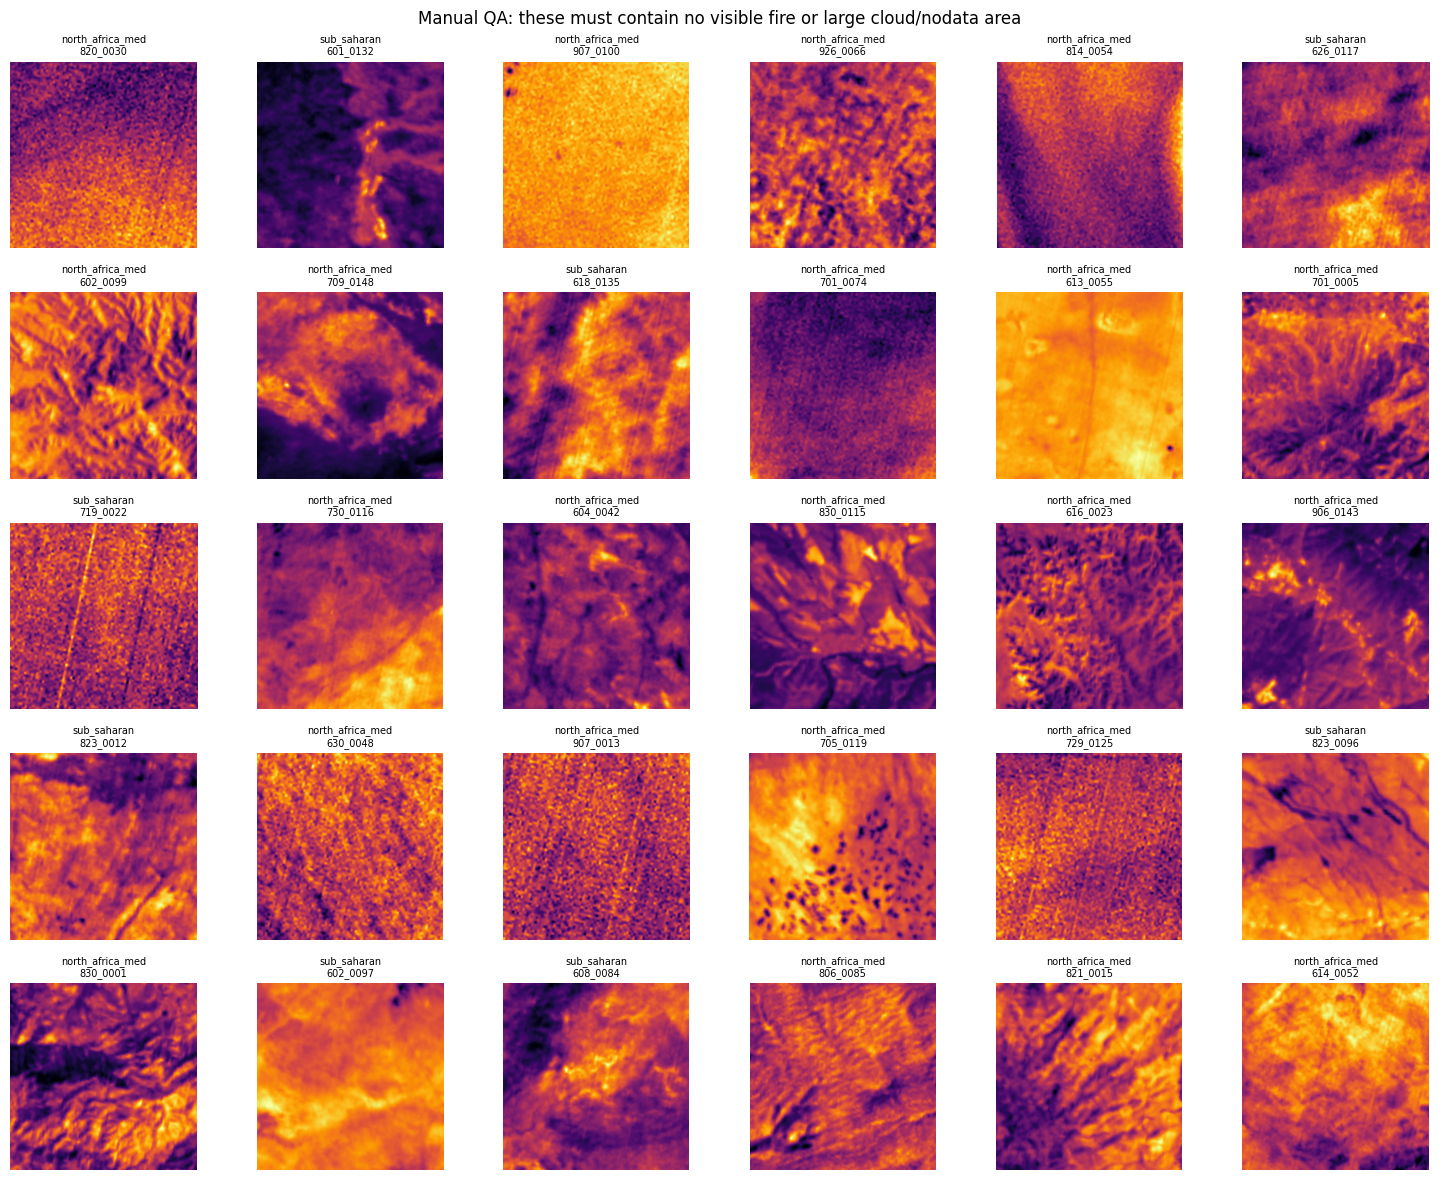

In [17]:
import matplotlib.pyplot as plt

assert len(gee_negative_inventory) > 0, "No patches downloaded."

qa_sample = gee_negative_inventory.sample(
    min(30, len(gee_negative_inventory)),
    random_state=SEED,
)

fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.ravel()

for ax, row in zip(axes, qa_sample.itertuples()):
    with rasterio.open(row.image_path) as src:
        b10 = src.read(9)  # B10 is band 9 in the exported ten-band stack.

    ax.imshow(b10, cmap="inferno")
    ax.set_title(row.region, fontsize=8)
    ax.axis("off")
    ax.set_title(
    f"{row.region}\n{row.stem[-8:]}",
    fontsize=7,
)

for ax in axes[len(qa_sample):]:
    ax.axis("off")

plt.suptitle("Manual QA: these must contain no visible fire or large cloud/nodata area")
plt.tight_layout()
plt.show()

In [18]:
# ================================================================
# STORAGE-SAFE SUBSET EXTRACTION
# Keeps 8,000 image patches, their three algorithmic masks only.
# ================================================================
import random, re, shutil, tempfile, zipfile
from pathlib import Path
from tqdm.auto import tqdm

SEED = 42
MAX_PATCHES = 8000
MAX_PATCHES_PER_SCENE = 20
ALGORITHMS = ("Kumar-Roy", "Murphy", "Schroeder")

PREPARED_ROOT = Path("/content/africa_prepared")
PATCH_DIR = PREPARED_ROOT / "patches"
ALGORITHM_MASK_DIR = PREPARED_ROOT / "masks" / "algorithmic"

# Rebuild only when changing the selected subset.
!rm -rf /content/africa_prepared
PATCH_DIR.mkdir(parents=True, exist_ok=True)
ALGORITHM_MASK_DIR.mkdir(parents=True, exist_ok=True)

def scene_id(member):
    return re.sub(r"(_masks)?\.zip$", "", Path(member).name)

def canonical_patch(mask_name):
    return re.sub(r"_(Kumar-Roy|Murphy|Schroeder)_p", "_p", Path(mask_name).name)

def open_nested(archive_path, member):
    buffer = tempfile.SpooledTemporaryFile(max_size=256 * 1024 * 1024)
    with zipfile.ZipFile(archive_path, "r") as archive:
        with archive.open(member) as src:
            shutil.copyfileobj(src, buffer)
    buffer.seek(0)
    return buffer, zipfile.ZipFile(buffer, "r")

with zipfile.ZipFile(AFRICA_ARCHIVE, "r") as archive:
    members = archive.namelist()

image_members = [m for m in members if re.fullmatch(r"z\d+\.zip", Path(m).name)]
mask_members = [m for m in members if re.fullmatch(r"z\d+_masks\.zip", Path(m).name)]
print("Image scene archives:", len(image_members), "Mask scene archives:", len(mask_members))

rng = random.Random(SEED)
rng.shuffle(image_members)
selected_patches, selected_scenes = set(), set()

for member in tqdm(image_members, desc="Extracting image patches"):
    if len(selected_patches) >= MAX_PATCHES:
        break
    buffer, nested = open_nested(AFRICA_ARCHIVE, member)
    try:
        infos = [i for i in nested.infolist() if not i.is_dir() and i.filename.lower().endswith(".tif")]
        rng.shuffle(infos)
        for info in infos[:MAX_PATCHES_PER_SCENE]:
            if len(selected_patches) >= MAX_PATCHES:
                break
            name = Path(info.filename).name
            with nested.open(info) as src, open(PATCH_DIR / name, "wb") as dst:
                shutil.copyfileobj(src, dst)
            selected_patches.add(name)
            selected_scenes.add(scene_id(member))
    finally:
        nested.close(); buffer.close()

mask_by_scene = {scene_id(m): m for m in mask_members}
saved_masks = 0
for sid in tqdm(sorted(selected_scenes), desc="Extracting matching masks"):
    member = mask_by_scene.get(sid)
    if member is None:
        continue
    buffer, nested = open_nested(AFRICA_ARCHIVE, member)
    try:
        for info in nested.infolist():
            name = Path(info.filename).name
            if info.is_dir() or not name.lower().endswith(".tif"):
                continue
            if not any(f"_{algorithm}_p" in name for algorithm in ALGORITHMS):
                continue
            if canonical_patch(name) not in selected_patches:
                continue
            with nested.open(info) as src, open(ALGORITHM_MASK_DIR / name, "wb") as dst:
                shutil.copyfileobj(src, dst)
            saved_masks += 1
    finally:
        nested.close(); buffer.close()

print("Images:", len(selected_patches), "algorithmic masks:", saved_masks)
!df -h /content


Image scene archives: 513 Mask scene archives: 513


Extracting image patches:   0%|          | 0/513 [00:00<?, ?it/s]

Extracting matching masks:   0%|          | 0/513 [00:00<?, ?it/s]

Images: 5970 algorithmic masks: 13141
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   87G   27G  77% /


In [19]:
# ================================================================
# STRICT VOTING + DATA EXPLORATION + SAFE NON-FIRE PATCHES
# A patch with exactly one label algorithm is uncertain and excluded.
# A patch with zero label algorithms is a non-fire candidate under the
# ActiveFire dataset convention (only fire masks are stored).
# ================================================================
import re
from collections import defaultdict
import numpy as np
import pandas as pd
import rasterio
from tqdm.auto import tqdm

VOTING_DIR = PREPARED_ROOT / "masks" / "voting_strict"
NONFIRE_DIR = PREPARED_ROOT / "masks" / "nonfire_generated"
VOTING_DIR.mkdir(parents=True, exist_ok=True)
NONFIRE_DIR.mkdir(parents=True, exist_ok=True)

def algorithm_name(stem):
    low = stem.lower()
    if "kumar-roy" in low or "kumar_roy" in low: return "kumar_roy"
    if "murphy" in low: return "murphy"
    if "schroeder" in low: return "schroeder"
    return None

def image_stem(mask_stem):
    return re.sub(r"_(Kumar[-_]?Roy|Murphy|Schroeder)_p", "_p", mask_stem, flags=re.I)

image_files = {p.stem: p for p in PATCH_DIR.glob("*.tif")}
masks_by_image = defaultdict(dict)
for mask_file in ALGORITHM_MASK_DIR.glob("*.tif"):
    algorithm = algorithm_name(mask_file.stem)
    target = image_stem(mask_file.stem)
    if algorithm and target in image_files:
        masks_by_image[target][algorithm] = mask_file

strict_records, coverage_records = [], []
for stem, image_file in tqdm(image_files.items(), desc="Creating voting masks"):
    sources = masks_by_image.get(stem, {})
    coverage_records.append({"stem": stem, "image_path": str(image_file), "n_label_algorithms": len(sources)})
    if len(sources) < 2:
        continue
    masks, profile = [], None
    for algorithm in ("kumar_roy", "murphy", "schroeder"):
        path = sources.get(algorithm)
        if path is None:
            continue
        with rasterio.open(path) as src:
            masks.append((src.read(1) > 0).astype(np.uint8))
            if profile is None:
                profile = src.profile.copy()
    vote = (np.sum(masks, axis=0) >= 2).astype(np.uint8)
    profile.pop("blockxsize", None); profile.pop("blockysize", None); profile.pop("tiled", None)
    profile.update(driver="GTiff", count=1, dtype="uint8", nodata=0, compress="lzw")
    out = VOTING_DIR / f"{stem}_voting.tif"
    with rasterio.open(out, "w", **profile) as dst:
        dst.write(vote, 1)
    match = re.search(r"LC08_[A-Z0-9]+_(\d{3})(\d{3})_", stem)
    strict_records.append({"stem": stem, "image_path": str(image_file), "mask_path": str(out),
                           "n_label_algorithms": len(masks), "fire_pixels": int(vote.sum()),
                           "path": int(match.group(1)) if match else None,
                           "row": int(match.group(2)) if match else None})

strict_inventory = pd.DataFrame(strict_records)
coverage = pd.DataFrame(coverage_records)
print("Label-source coverage:")
display(coverage.n_label_algorithms.value_counts().sort_index())
print("Strict pairs:", len(strict_inventory), "strict zero masks:", int((strict_inventory.fire_pixels == 0).sum()))

positive = strict_inventory[strict_inventory.fire_pixels > 0].copy()
strict_zero = strict_inventory[strict_inventory.fire_pixels == 0].copy()
candidates = coverage[coverage.n_label_algorithms == 0].copy()
N_NEGATIVES = min(1200, len(candidates))
if N_NEGATIVES == 0:
    print("WARNING: This Africa archive contains only fire-candidate patches. "
          "No genuine image-level negatives are available; training will remain strict-only. "
          "Do not convert one-algorithm patches into negative labels.")
    negatives = candidates.iloc[0:0].copy()
else:
    negatives = candidates.sample(N_NEGATIVES, random_state=SEED)

negative_records = []
for row in tqdm(negatives.itertuples(index=False), total=len(negatives), desc="Writing zero masks"):
    source, out = Path(row.image_path), NONFIRE_DIR / f"{row.stem}_nonfire.tif"
    with rasterio.open(source) as src:
        profile = src.profile.copy()
        profile.pop("blockxsize", None); profile.pop("blockysize", None); profile.pop("tiled", None)
        profile.update(driver="GTiff", count=1, dtype="uint8", nodata=0, compress="lzw")
        zeros = np.zeros((src.height, src.width), dtype=np.uint8)
    with rasterio.open(out, "w", **profile) as dst:
        dst.write(zeros, 1)
    match = re.search(r"LC08_[A-Z0-9]+_(\d{3})(\d{3})_", row.stem)
    negative_records.append({"stem": row.stem, "image_path": str(source), "mask_path": str(out),
                             "n_label_algorithms": 0, "fire_pixels": 0,
                             "path": int(match.group(1)) if match else None,
                             "row": int(match.group(2)) if match else None,
                             "sample_type": "nonfire"})

positive["sample_type"] = "strict_fire"
strict_zero["sample_type"] = "strict_zero"
df_all = pd.concat([positive, strict_zero, pd.DataFrame(negative_records)], ignore_index=True)
STRICT_INVENTORY = PREPARED_ROOT / "training_inventory_strict_voting.csv"
strict_inventory.to_csv(STRICT_INVENTORY, index=False)

print("Strict inventory saved:", STRICT_INVENTORY)

print("Balanced training inventory:")
display(df_all.sample_type.value_counts())
print("Zero-fire patches:", int((df_all.fire_pixels == 0).sum()), "/", len(df_all))
display(df_all.fire_pixels.describe(percentiles=[.1, .25, .5, .75, .9, .99]))


Creating voting masks:   0%|          | 0/5970 [00:00<?, ?it/s]

Label-source coverage:


,count
n_label_algorithms,
1,1761
2,1247
3,2962


Strict pairs: 4209 strict zero masks: 34


Writing zero masks: 0it [00:00, ?it/s]

Strict inventory saved: /content/africa_prepared/training_inventory_strict_voting.csv
Balanced training inventory:


,count
sample_type,
strict_fire,4175
strict_zero,34


Zero-fire patches: 34 / 4209


,fire_pixels
count,4209.000000
mean,8.687337
std,23.105944
min,0.000000
10%,1.000000
25%,1.000000
50%,3.000000
75%,6.000000
90%,18.000000
99%,114.000000


In [20]:
strict_df = pd.read_csv(
    "/content/africa_prepared/training_inventory_strict_voting.csv"
)

strict_df["sample_type"] = np.where(
    strict_df["fire_pixels"] > 0,
    "strict_fire",
    "strict_zero",
)

v3_df = pd.concat(
    [strict_df, gee_negative_inventory],
    ignore_index=True,
)

assert len(gee_negative_inventory) > 0, (
    "No GEE no-fire patches were created. Do not call this v3 yet."
)

V3_INVENTORY = Path(
    "/content/africa_prepared/training_inventory_v3_with_gee_negatives.csv"
)

v3_df.to_csv(V3_INVENTORY, index=False)

# This is the dataframe used by all following Gate 1 and training cells.
df_all = v3_df.copy()

print("V3 inventory:")
display(df_all["sample_type"].value_counts())
print("Saved:", V3_INVENTORY)

V3 inventory:


,count
sample_type,
strict_fire,4175
gee_screened_nonfire,127
strict_zero,34


Saved: /content/africa_prepared/training_inventory_v3_with_gee_negatives.csv


In [21]:
# ================================================================
# PROJECT WORKFLOW + GATE 1 GROUND CURATION
# Gate 1 uses B10 and B11; training itself remains B10-only.
# ================================================================
import sys, random
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader

PROJECT_ROOT = Path("/content/thermal-edge-fire")
OUTPUT_DIR = PROJECT_ROOT / "reports" / "training_africa_tiny_unet_v3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from fireedge.io import read_image, read_mask
from fireedge.data.dataset import ActiveFireDataset
from fireedge.validation import GroundGateValidator, Status, ValidatorConfig, calibrate_from_frames

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda": print("GPU:", torch.cuda.get_device_name(0))

assert df_all.image_path.map(lambda p: Path(p).exists()).all()
assert df_all.mask_path.map(lambda p: Path(p).exists()).all()

# Calibrate Gate 1 thresholds from a small representative B10/B11 sample.
calibration_df = df_all.sample(min(64, len(df_all)), random_state=SEED)
frames = [read_image(path, channels=(8, 9)).astype(np.float32) for path in calibration_df.image_path]
cfg_b10 = calibrate_from_frames((frame[0] for frame in frames), ValidatorConfig(hot_pixel_policy="flag"))
cfg_b11 = calibrate_from_frames((frame[1] for frame in frames), ValidatorConfig(hot_pixel_policy="flag"))
ground_gate = GroundGateValidator([cfg_b10, cfg_b11])

gate_rows = []
for row in tqdm(df_all.itertuples(), total=len(df_all), desc="Gate 1 ground curation"):
    report = ground_gate.validate(read_image(row.image_path, channels=(8, 9)).astype(np.float32))
    gate_rows.append({"stem": row.stem, "gate_status": report.status.value, "gate_reasons": "|".join(report.reasons)})

gate_report = pd.DataFrame(gate_rows)
gate_report.to_csv(OUTPUT_DIR / "gate1_ground_audit.csv", index=False)
display(gate_report.gate_status.value_counts())

rejected = set(gate_report.loc[gate_report.gate_status == Status.REJECT.value, "stem"])
df_all = df_all[~df_all.stem.isin(rejected)].copy()
assert len(df_all) > 100, "Gate 1 rejected too much data; inspect gate1_ground_audit.csv."
print("Pairs retained after Gate 1:", len(df_all))


Device: cuda
GPU: Tesla T4


Gate 1 ground curation:   0%|          | 0/4336 [00:00<?, ?it/s]

,count
gate_status,
PASS_WITH_FLAGS,4041
REJECT,295


Pairs retained after Gate 1: 4041


In [22]:
rejected_reasons = (
    gate_report.loc[
        gate_report["gate_status"] == "REJECT",
        "gate_reasons",
    ]
    .str.split("|")
    .explode()
    .value_counts()
)

display(rejected_reasons)

,count
gate_reasons,
ch1:NODATA_EXCESS,286
ch0:STRIPING,285
ch1:STRIPING,285
ch0:NODATA_EXCESS,282
ch0:HOT_PIXELS,200
ch1:HOT_PIXELS,194
ch1:HIGH_NOISE,19
ch0:HIGH_NOISE,15
ch1:EMPTY_FRAME,10


In [23]:
gate_by_type = (
    v3_df[["stem", "sample_type"]]
    .merge(gate_report[["stem", "gate_status"]], on="stem", how="left")
    .groupby(["sample_type", "gate_status"])
    .size()
    .unstack(fill_value=0)
)

display(gate_by_type)

print(
    "GEE negatives retained:",
    int(
        (
            (v3_df["sample_type"] == "gee_screened_nonfire")
            & (~v3_df["stem"].isin(rejected))
        ).sum()
    )
)

gate_status,PASS_WITH_FLAGS,REJECT
sample_type,,
gee_screened_nonfire,125,2
strict_fire,3887,288
strict_zero,29,5


GEE negatives retained: 125


In [24]:
# ================================================================
# SCENE-SAFE SPLIT + FINAL BALANCE AUDIT — V3
# ================================================================

df_all = df_all.copy()

# ActiveFire patch names end in _pXXXXX: group by their parent Landsat scene.
df_all["parent_scene"] = df_all["stem"].str.replace(
    r"_p\d+$",
    "",
    regex=True,
)

# GEE negatives may share the same original Landsat acquisition.
# Group them using the Landsat product ID, not their unique patch filename.
gee_rows = df_all["sample_type"].eq("gee_screened_nonfire")

df_all.loc[gee_rows, "parent_scene"] = (
    "GEE_" + df_all.loc[gee_rows, "landsat_product_id"].astype(str)
)

assert df_all["parent_scene"].notna().all()

rng = np.random.default_rng(SEED)

scenes = df_all["parent_scene"].drop_duplicates().to_numpy()
rng.shuffle(scenes)

n_test = max(1, round(0.15 * len(scenes)))
n_val = max(1, round(0.15 * len(scenes)))

test_scenes = set(scenes[:n_test])
val_scenes = set(scenes[n_test:n_test + n_val])
train_scenes = set(scenes[n_test + n_val:])

train_df = df_all[df_all["parent_scene"].isin(train_scenes)].copy()
val_df = df_all[df_all["parent_scene"].isin(val_scenes)].copy()
test_df = df_all[df_all["parent_scene"].isin(test_scenes)].copy()

for name, part in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    assert not part.empty

    part.to_csv(OUTPUT_DIR / f"{name}_inventory.csv", index=False)

    print(
        f"{name:10s} patches={len(part):,} "
        f"scenes={part['parent_scene'].nunique():,} "
        f"zero_masks={(part['fire_pixels'] == 0).sum():,} "
        f"fire_pixels={part['fire_pixels'].sum():,}"
    )

    display(part["sample_type"].value_counts().rename(name))

# No scene may appear in more than one split.
assert not (set(train_df["parent_scene"]) & set(val_df["parent_scene"]))
assert not (set(train_df["parent_scene"]) & set(test_df["parent_scene"]))
assert not (set(val_df["parent_scene"]) & set(test_df["parent_scene"]))

train      patches=2,779 scenes=388 zero_masks=110 fire_pixels=22,697


,train
sample_type,
strict_fire,2669
gee_screened_nonfire,93
strict_zero,17


validation patches=640 scenes=83 zero_masks=20 fire_pixels=5,059


,validation
sample_type,
strict_fire,620
gee_screened_nonfire,17
strict_zero,3


test       patches=622 scenes=83 zero_masks=24 fire_pixels=6,308


,test
sample_type,
strict_fire,598
gee_screened_nonfire,15
strict_zero,9


In [29]:
# ================================================================
# B10 LOADERS, BALANCED SAMPLING, AND LIGHTWEIGHT U-NET CANDIDATES
# ================================================================

from torch.utils.data import DataLoader, WeightedRandomSampler

BATCH_SIZE = 8 if device.type == "cuda" else 2

# Rasterio + Colab worker processes can crash with GeoTIFF inputs.
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# Oversample true zero-mask/no-fire training patches to ~25% per epoch.
is_negative = train_df["fire_pixels"].to_numpy() == 0
n_negative = int(is_negative.sum())
n_positive = int((~is_negative).sum())

assert n_negative > 0, "No training negatives available."

negative_weight = n_positive / (3 * n_negative)
sample_weights = np.where(is_negative, negative_weight, 1.0)

train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(train_ds),
    replacement=True,
)

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
}

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

print(f"Training positive/fire patches: {n_positive:,}")
print(f"Training zero-mask/no-fire patches: {n_negative:,}")
print(f"Negative sampling weight: {negative_weight:.2f}")
print("Expected negative share per sampled epoch: ~25%")


class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(cin, cout, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class TinyUNet(nn.Module):
    def __init__(self, base=8):
        super().__init__()

        self.e1 = ConvBlock(1, base)
        self.e2 = ConvBlock(base, base * 2)
        self.e3 = ConvBlock(base * 2, base * 4)

        self.pool = nn.MaxPool2d(2)
        self.mid = ConvBlock(base * 4, base * 8)

        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, 2, 2)
        self.d3 = ConvBlock(base * 8, base * 4)

        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, 2)
        self.d2 = ConvBlock(base * 4, base * 2)

        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, 2)
        self.d1 = ConvBlock(base * 2, base)

        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))

        middle = self.mid(self.pool(e3))

        d3 = self.d3(torch.cat([self.u3(middle), e3], dim=1))
        d2 = self.d2(torch.cat([self.u2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], dim=1))

        return self.out(d1)


MODEL_CANDIDATES = {
    "tiny_unet_b8": 8,    # approximately 121k parameters
    "tiny_unet_b12": 12,  # approximately 271k parameters
    "tiny_unet_b16": 16,  # approximately 480k parameters
}

for name, base in MODEL_CANDIDATES.items():
    candidate = TinyUNet(base=base)
    n_params = sum(p.numel() for p in candidate.parameters())
    print(f"{name:15s} | base={base:2d} | parameters={n_params:,}")

x, y = next(iter(train_loader))
print("Batch:", x.shape, y.shape)
print("Input range:", (x.min().item(), x.max().item()))
print("Mask values:", y.unique())

Training positive/fire patches: 2,669
Training zero-mask/no-fire patches: 110
Negative sampling weight: 8.09
Expected negative share per sampled epoch: ~25%
tiny_unet_b8    | base= 8 | parameters=121,033
tiny_unet_b12   | base=12 | parameters=271,693
tiny_unet_b16   | base=16 | parameters=482,449
Batch: torch.Size([8, 1, 256, 256]) torch.Size([8, 1, 256, 256])
Input range: (0.14349094033241272, 0.3469761610031128)
Mask values: tensor([0., 1.])


In [30]:
# Hide harmless repeated GEE GeoTIFF metadata warnings.
import logging

logging.getLogger("rasterio._env").setLevel(logging.ERROR)

In [31]:
# ================================================================
# TRAIN ALL CANDIDATES — CHECKPOINTS SELECTED BY VALIDATION DICE
# ================================================================

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=0.75, eps=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.eps = eps

    def forward(self, logits, targets):
        probabilities = torch.sigmoid(logits)
        dimensions = (1, 2, 3)

        true_positive = (probabilities * targets).sum(dimensions)
        false_positive = (probabilities * (1 - targets)).sum(dimensions)
        false_negative = ((1 - probabilities) * targets).sum(dimensions)

        tversky = (
            (true_positive + self.eps)
            / (
                true_positive
                + self.alpha * false_positive
                + self.beta * false_negative
                + self.eps
            )
        )

        return ((1 - tversky) ** self.gamma).mean()


bce = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([25.0], device=device)
)

tversky_loss = FocalTverskyLoss()

def loss_fn(logits, targets):
    return 0.3 * bce(logits, targets) + 0.7 * tversky_loss(logits, targets)


@torch.no_grad()
def evaluate(model, loader, threshold=0.20):
    model.eval()

    tp = 0
    fp = 0
    fn = 0
    losses = []

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        losses.append(loss_fn(logits, masks).item())

        predictions = torch.sigmoid(logits) >= threshold
        targets = masks.bool()

        tp += (predictions & targets).sum().item()
        fp += (predictions & ~targets).sum().item()
        fn += (~predictions & targets).sum().item()

    recall = tp / (tp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-9)

    return {
        "loss": float(np.mean(losses)),
        "recall": recall,
        "precision": precision,
        "iou": iou,
        "dice": dice,
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }


EPOCHS = 30
PATIENCE = 6
MODEL_TRAINING_RESULTS = []

for model_name, model_base in MODEL_CANDIDATES.items():
    print("\n" + "=" * 72)
    print(f"TRAINING {model_name} — base channels: {model_base}")
    print("=" * 72)

    torch.manual_seed(SEED)

    model = TinyUNet(base=model_base).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )

    best_dice = -1.0
    stale_epochs = 0
    history = []

    checkpoint_path = OUTPUT_DIR / f"best_{model_name}_v3.pt"

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []

        for images, masks in train_loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = loss_fn(logits, masks)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_losses.append(loss.item())

        # Fixed threshold is used only for early stopping.
        # Final threshold is optimized later on validation data.
        validation_metrics = evaluate(model, val_loader, threshold=0.20)

        row = {
            "model_name": model_name,
            "model_base": model_base,
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            **validation_metrics,
        }
        history.append(row)

        print(
            f"{model_name} | {epoch:02d} "
            f"train={row['train_loss']:.4f} "
            f"val={row['loss']:.4f} "
            f"recall={row['recall']:.3f} "
            f"precision={row['precision']:.3f} "
            f"dice={row['dice']:.3f}"
        )

        if validation_metrics["dice"] > best_dice:
            best_dice = validation_metrics["dice"]
            stale_epochs = 0

            torch.save(
                {
                    "model_name": model_name,
                    "model_base": model_base,
                    "model_state": model.state_dict(),
                    "epoch": epoch,
                    "validation_at_020": validation_metrics,
                },
                checkpoint_path,
            )
        else:
            stale_epochs += 1

            if stale_epochs >= PATIENCE:
                print(f"Early stopping {model_name} at epoch {epoch}.")
                break

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        OUTPUT_DIR / f"history_{model_name}_v3.csv",
        index=False,
    )

    MODEL_TRAINING_RESULTS.append(
        {
            "model_name": model_name,
            "model_base": model_base,
            "parameters": sum(p.numel() for p in model.parameters()),
            "best_dice_at_threshold_020": best_dice,
            "best_checkpoint": str(checkpoint_path),
            "epochs_completed": len(history),
        }
    )

    del model, optimizer
    if device.type == "cuda":
        torch.cuda.empty_cache()

model_training_df = pd.DataFrame(MODEL_TRAINING_RESULTS)
model_training_df.to_csv(
    OUTPUT_DIR / "candidate_training_summary_v3.csv",
    index=False,
)

display(
    model_training_df.sort_values(
        "best_dice_at_threshold_020",
        ascending=False,
    )
)


TRAINING tiny_unet_b8 — base channels: 8
tiny_unet_b8 | 01 train=0.8266 val=0.7558 recall=0.097 precision=0.001 dice=0.002
tiny_unet_b8 | 02 train=0.7315 val=0.7206 recall=0.168 precision=0.004 dice=0.008
tiny_unet_b8 | 03 train=0.7113 val=0.7079 recall=0.214 precision=0.070 dice=0.105
tiny_unet_b8 | 04 train=0.7039 val=0.7076 recall=0.368 precision=0.006 dice=0.011
tiny_unet_b8 | 05 train=0.6974 val=0.7004 recall=0.291 precision=0.005 dice=0.011
tiny_unet_b8 | 06 train=0.6889 val=0.6862 recall=0.301 precision=0.064 dice=0.106
tiny_unet_b8 | 07 train=0.6780 val=0.6816 recall=0.256 precision=0.232 dice=0.243
tiny_unet_b8 | 08 train=0.6761 val=0.6670 recall=0.351 precision=0.093 dice=0.147
tiny_unet_b8 | 09 train=0.6689 val=0.6714 recall=0.279 precision=0.349 dice=0.310
tiny_unet_b8 | 10 train=0.6672 val=0.6658 recall=0.318 precision=0.260 dice=0.286
tiny_unet_b8 | 11 train=0.6633 val=0.6751 recall=0.224 precision=0.472 dice=0.304
tiny_unet_b8 | 12 train=0.6667 val=0.6632 recall=0.337 p

,model_name,model_base,parameters,best_dice_at_threshold_020,best_checkpoint,epochs_completed
0,tiny_unet_b8,8,121033,0.367418,/content/thermal-edge-fire/reports/training_af...,30
2,tiny_unet_b16,16,482449,0.320278,/content/thermal-edge-fire/reports/training_af...,18
1,tiny_unet_b12,12,271693,0.279075,/content/thermal-edge-fire/reports/training_af...,11


In [32]:
!pip -q install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 21.5 MB/s eta 0:00:00


BEST MODEL SELECTED FROM VALIDATION:


,best_model_name,best_model_base,final_threshold,validation_dice,validation_iou,validation_recall,validation_precision
0,tiny_unet_b8,8,0.35,0.369614,0.226704,0.307768,0.462567



Top ten model/threshold combinations:


,model_name,model_base,threshold,loss,recall,precision,iou,dice,tp,fp,fn
6,tiny_unet_b8,8,0.35,0.661788,0.307768,0.462567,0.226704,0.369614,1557,1809,3502
7,tiny_unet_b8,8,0.40,0.661788,0.305989,0.466546,0.226680,0.369583,1548,1770,3511
8,tiny_unet_b8,8,0.45,0.661788,0.303222,0.471565,0.226320,0.369105,1534,1719,3525
4,tiny_unet_b8,8,0.25,0.661788,0.311919,0.449445,0.225686,0.368261,1578,1933,3481
9,tiny_unet_b8,8,0.50,0.661788,0.300257,0.476026,0.225672,0.368242,1519,1672,3540
5,tiny_unet_b8,8,0.30,0.661788,0.308954,0.455154,0.225541,0.368068,1563,1871,3496
3,tiny_unet_b8,8,0.20,0.661788,0.314291,0.442158,0.225053,0.367418,1590,2006,3469
2,tiny_unet_b8,8,0.15,0.661788,0.318047,0.432992,0.224533,0.366724,1609,2107,3450
1,tiny_unet_b8,8,0.10,0.661788,0.322593,0.420185,0.223225,0.364978,1632,2252,3427
0,tiny_unet_b8,8,0.05,0.661788,0.331488,0.399571,0.221269,0.362360,1677,2520,3382



HELD-OUT TEST METRICS — SELECTED MODEL
{'model_name': 'tiny_unet_b8', 'model_base': 8, 'final_threshold': 0.35000000000000003, 'loss': 0.6515138149261475, 'recall': 0.3871274571971485, 'precision': 0.42249134948089573, 'iou': 0.25316193240718915, 'dice': 0.40403706154860985, 'tp': 2442, 'fp': 3338, 'fn': 3866}


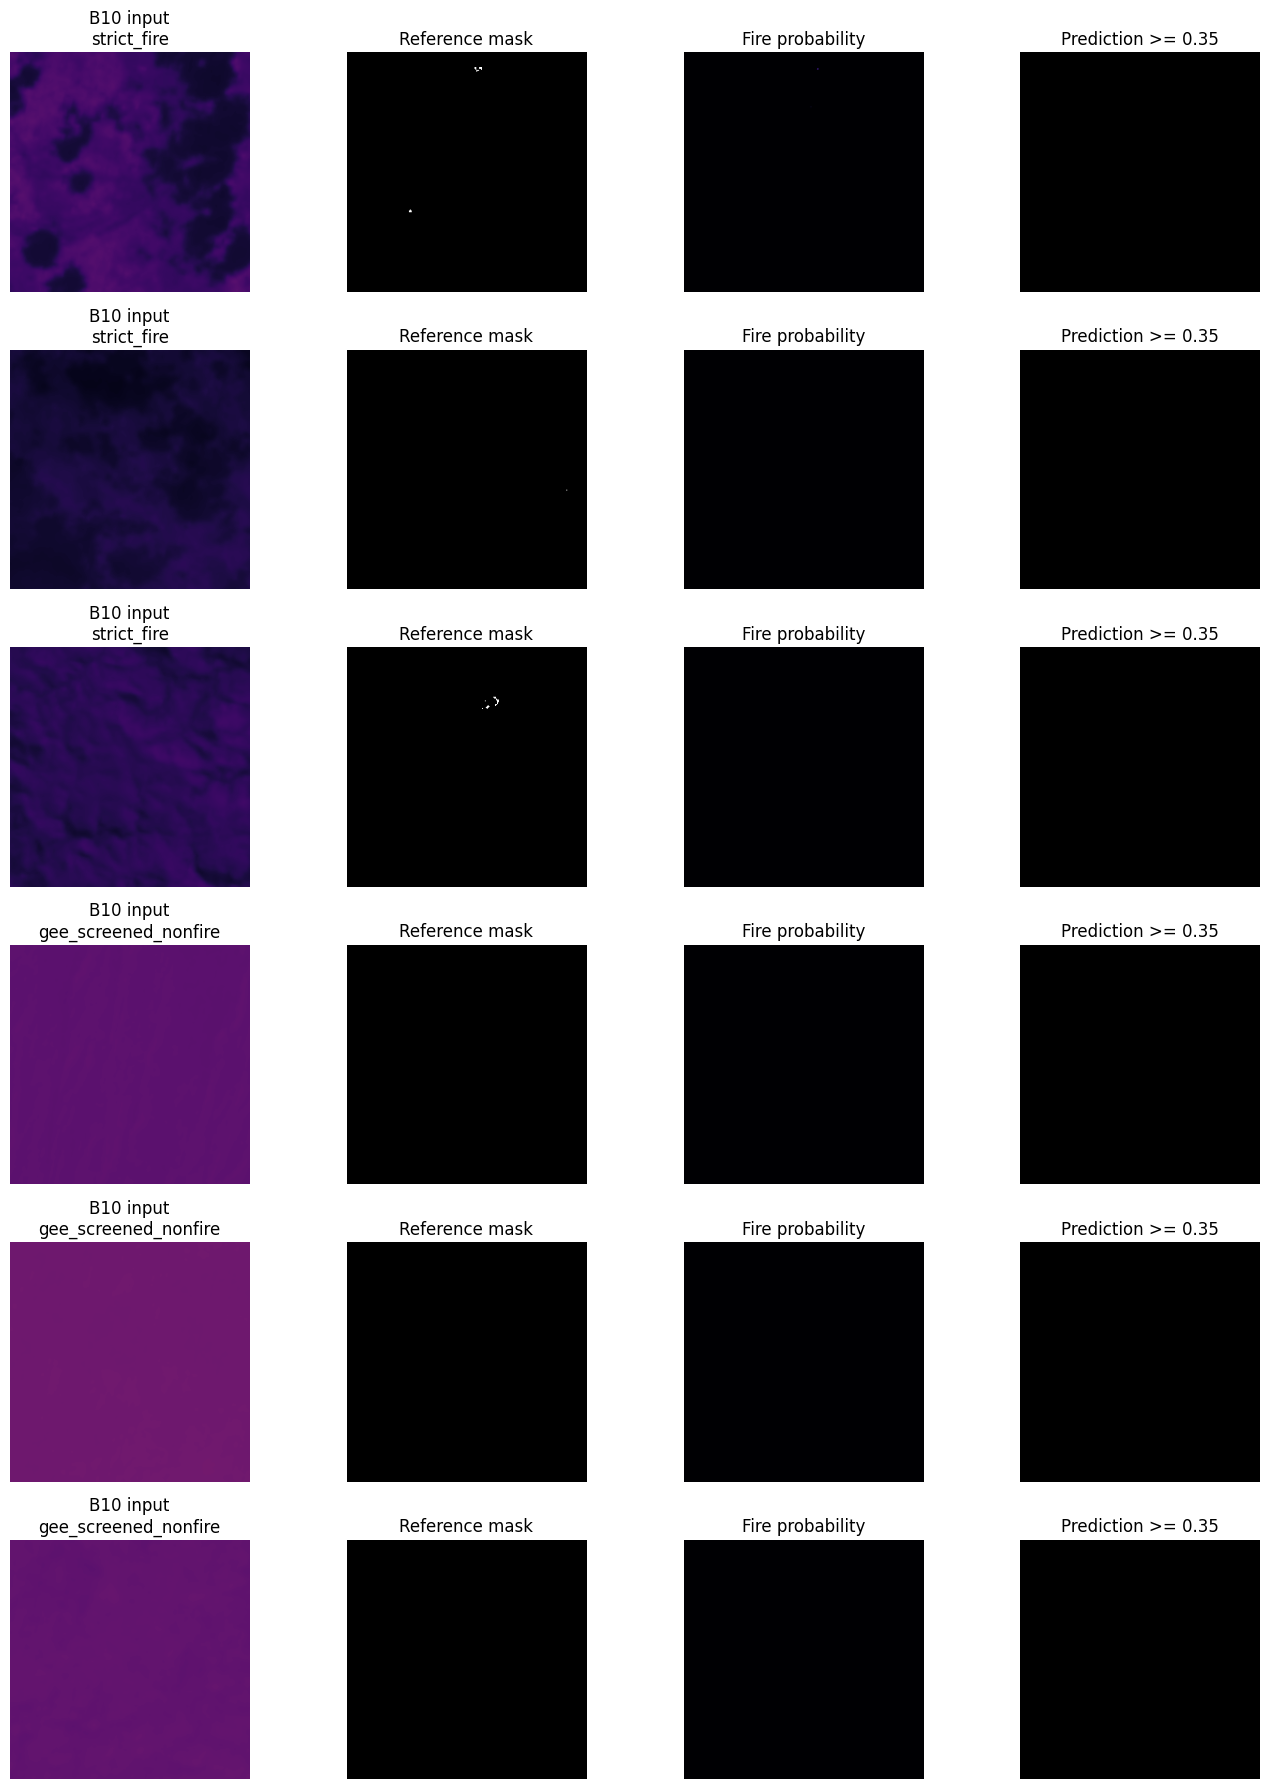

W0924 18:44:35.940000 1301 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `TinyUNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TinyUNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX verified: /content/thermal-edge-fire/reports/training_africa_tiny_unet_v3/tiny_unet_b8_africa_v3.onnx
Saved results to: /content/drive/MyDrive/africa_tiny_unet_v3_model_comparison.zip


In [33]:
# ================================================================
# SELECT BEST MODEL + BEST THRESHOLD ON VALIDATION ONLY
# THEN EVALUATE THE WINNER ON THE HELD-OUT TEST SET
# ================================================================

!pip -q install onnx onnxscript

import gc
import shutil
import zipfile
import onnx

thresholds = np.arange(0.05, 0.51, 0.05)
all_validation_results = []

# For every model:
# 1. Load its validation-best checkpoint.
# 2. Test thresholds only on validation data.
# 3. Retain its best validation Dice threshold.
for model_name, model_base in MODEL_CANDIDATES.items():
    checkpoint_path = OUTPUT_DIR / f"best_{model_name}_v3.pt"

    assert checkpoint_path.exists(), f"Missing checkpoint: {checkpoint_path}"

    model = TinyUNet(base=model_base).to(device)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model.load_state_dict(checkpoint["model_state"])

    threshold_results = pd.DataFrame(
        [
            {
                "model_name": model_name,
                "model_base": model_base,
                "threshold": float(threshold),
                **evaluate(model, val_loader, threshold=float(threshold)),
            }
            for threshold in thresholds
        ]
    )

    threshold_results.to_csv(
        OUTPUT_DIR / f"validation_threshold_sweep_{model_name}_v3.csv",
        index=False,
    )

    all_validation_results.append(threshold_results)

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

validation_results = pd.concat(
    all_validation_results,
    ignore_index=True,
)

validation_results.to_csv(
    OUTPUT_DIR / "all_candidate_validation_thresholds_v3.csv",
    index=False,
)

# This is the only selection rule:
# highest validation Dice; precision resolves an exact Dice tie.
best_choice = validation_results.sort_values(
    ["dice", "precision"],
    ascending=False,
).iloc[0]

BEST_MODEL_NAME = str(best_choice["model_name"])
BEST_MODEL_BASE = int(best_choice["model_base"])
FINAL_THRESHOLD = float(best_choice["threshold"])

selection_summary = pd.DataFrame(
    [
        {
            "best_model_name": BEST_MODEL_NAME,
            "best_model_base": BEST_MODEL_BASE,
            "final_threshold": FINAL_THRESHOLD,
            "validation_dice": float(best_choice["dice"]),
            "validation_iou": float(best_choice["iou"]),
            "validation_recall": float(best_choice["recall"]),
            "validation_precision": float(best_choice["precision"]),
        }
    ]
)

selection_summary.to_csv(
    OUTPUT_DIR / "best_model_selection_v3.csv",
    index=False,
)

print("BEST MODEL SELECTED FROM VALIDATION:")
display(selection_summary)

print("\nTop ten model/threshold combinations:")
display(
    validation_results.sort_values(
        ["dice", "precision"],
        ascending=False,
    ).head(10)
)

# Load only the selected model for the final, one-time held-out test.
best_checkpoint_path = OUTPUT_DIR / f"best_{BEST_MODEL_NAME}_v3.pt"

model = TinyUNet(base=BEST_MODEL_BASE).to(device)

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

test_metrics = evaluate(
    model,
    test_loader,
    threshold=FINAL_THRESHOLD,
)

test_results = {
    "model_name": BEST_MODEL_NAME,
    "model_base": BEST_MODEL_BASE,
    "final_threshold": FINAL_THRESHOLD,
    **test_metrics,
}

pd.DataFrame([test_results]).to_csv(
    OUTPUT_DIR / "heldout_test_metrics_best_model_v3.csv",
    index=False,
)

print("\nHELD-OUT TEST METRICS — SELECTED MODEL")
print(test_results)

# ================================================================
# VISUAL QA: STRICT-FIRE AND GEE NO-FIRE HELD-OUT TEST PATCHES
# ================================================================

qa_df = test_df.reset_index(drop=True).copy()
rng = np.random.default_rng(SEED)

fire_indices = qa_df.index[
    qa_df["sample_type"].eq("strict_fire")
].to_numpy()

gee_negative_indices = qa_df.index[
    qa_df["sample_type"].eq("gee_screened_nonfire")
].to_numpy()

assert len(fire_indices) > 0, "No strict-fire test patches found."
assert len(gee_negative_indices) > 0, "No GEE no-fire test patches found."

# Three fire examples and three independently screened no-fire examples.
selected_fire = rng.choice(
    fire_indices,
    size=min(3, len(fire_indices)),
    replace=False,
)

selected_negatives = rng.choice(
    gee_negative_indices,
    size=min(3, len(gee_negative_indices)),
    replace=False,
)

qa_indices = np.concatenate([selected_fire, selected_negatives])

qa_images = []
qa_masks = []

for index in qa_indices:
    image, mask = test_ds[int(index)]
    qa_images.append(image)
    qa_masks.append(mask)

images = torch.stack(qa_images)
masks = torch.stack(qa_masks)

model.eval()

with torch.no_grad():
    probabilities = torch.sigmoid(
        model(images.to(device, non_blocking=True))
    ).cpu()

n = len(qa_indices)

fig, axes = plt.subplots(
    n,
    4,
    figsize=(14, 3 * n),
    squeeze=False,
)

for plot_row, dataset_index in enumerate(qa_indices):
    sample = qa_df.iloc[int(dataset_index)]
    sample_type = sample["sample_type"]

    axes[plot_row, 0].imshow(
        images[plot_row, 0],
        cmap="inferno",
        vmin=0,
        vmax=1,
    )
    axes[plot_row, 0].set_title(f"B10 input\n{sample_type}")

    axes[plot_row, 1].imshow(
        masks[plot_row, 0],
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[plot_row, 1].set_title("Reference mask")

    axes[plot_row, 2].imshow(
        probabilities[plot_row, 0],
        cmap="magma",
        vmin=0,
        vmax=1,
    )
    axes[plot_row, 2].set_title("Fire probability")

    axes[plot_row, 3].imshow(
        probabilities[plot_row, 0] >= FINAL_THRESHOLD,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[plot_row, 3].set_title(
        f"Prediction >= {FINAL_THRESHOLD:.2f}"
    )

    for axis in axes[plot_row]:
        axis.axis("off")

plt.tight_layout()

figure_path = OUTPUT_DIR / "heldout_fire_and_gee_nonfire_qa_v3.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

# ONNX export for the selected model only.
onnx_path = OUTPUT_DIR / f"{BEST_MODEL_NAME}_africa_v3.onnx"
example = torch.zeros(1, 1, 256, 256, device=device)

torch.onnx.export(
    model,
    example,
    str(onnx_path),
    input_names=["thermal_b10"],
    output_names=["fire_logits"],
    opset_version=17,
)

onnx.checker.check_model(onnx.load(str(onnx_path)))
print("ONNX verified:", onnx_path)

# Archive all checkpoints, training histories, selection files, ONNX, and figures.
archive_path = Path("/content/africa_tiny_unet_v3_model_comparison.zip")

result_files = []
for pattern in ("*.pt", "*.onnx", "*.csv", "*.png"):
    result_files.extend(OUTPUT_DIR.glob(pattern))

with zipfile.ZipFile(
    archive_path,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for file_path in result_files:
        archive.write(file_path, arcname=file_path.name)

drive_path = Path("/content/drive/MyDrive") / archive_path.name
shutil.copy2(archive_path, drive_path)

print("Saved results to:", drive_path)

gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()